# 1. Audio Preprocessing and Visualization 

Develop a simple audio preprocessing and visualization notebook that displays different representations of an audio signal before and after preprocessing. 

## Dataset 

• Use any audio dataset of your choice that is appropriate for the given task 

## Tasks 

- Load an audio sample from the selected dataset. 

- Apply suitable preprocessing such as resampling, normalization, trimming or silence removal. 

- Display the waveform, Mel-spectrogram, MFCC heatmap and FFT spectrum. 

- Compare the original and preprocessed audio representations. 

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import scipy.fft
audio_path = "dataset/sample.mp3"

signal, sr = librosa.load(audio_path, sr=None)

print("Sampling Rate:", sr)
print("Duration:", len(signal)/sr, "seconds")

Sampling Rate: 48000
Duration: 5.784 seconds


In [3]:
from IPython.display import Audio, display

display(Audio(signal, rate=sr))

In [4]:
target_sr = 16000

signal_resampled = librosa.resample(
    signal,
    orig_sr=sr,
    target_sr=target_sr
)

signal_normalized = librosa.util.normalize(signal_resampled)

processed, _ = librosa.effects.trim(
    signal_normalized,
    top_db=20
)

In [5]:
display(Audio(processed, rate=target_sr))

In [6]:
import soundfile as sf

sf.write("dataset/processed.wav", processed, target_sr)

In [13]:
def plot_audio_features(audio, sr, title):

    fig, ax = plt.subplots(2,2, figsize=(15,10))

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=ax[0,0])
    ax[0,0].set_title(title + " Waveform")

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    img = librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis='time',
        y_axis='mel',
        ax=ax[0,1]
    )

    ax[0,1].set_title(title + " Mel Spectrogram")
    fig.colorbar(img, ax=ax[0,1])

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )

    img = librosa.display.specshow(
        mfcc,
        x_axis='time',
        ax=ax[1,0]
    )

    ax[1,0].set_title(title + " MFCC")
    fig.colorbar(img, ax=ax[1,0])

    # FFT
    fft = np.abs(scipy.fft.rfft(audio))
    freq = scipy.fft.rfftfreq(len(audio), d=1/sr)

    ax[1,1].plot(freq, fft)
    ax[1,1].set_xlim([0, sr/2])
    ax[1,1].set_title(title + " FFT Spectrum")
    ax[1,1].set_xlabel("Frequency (Hz)")
    ax[1,1].set_ylabel("Magnitude")

    plt.tight_layout()
    plt.show()

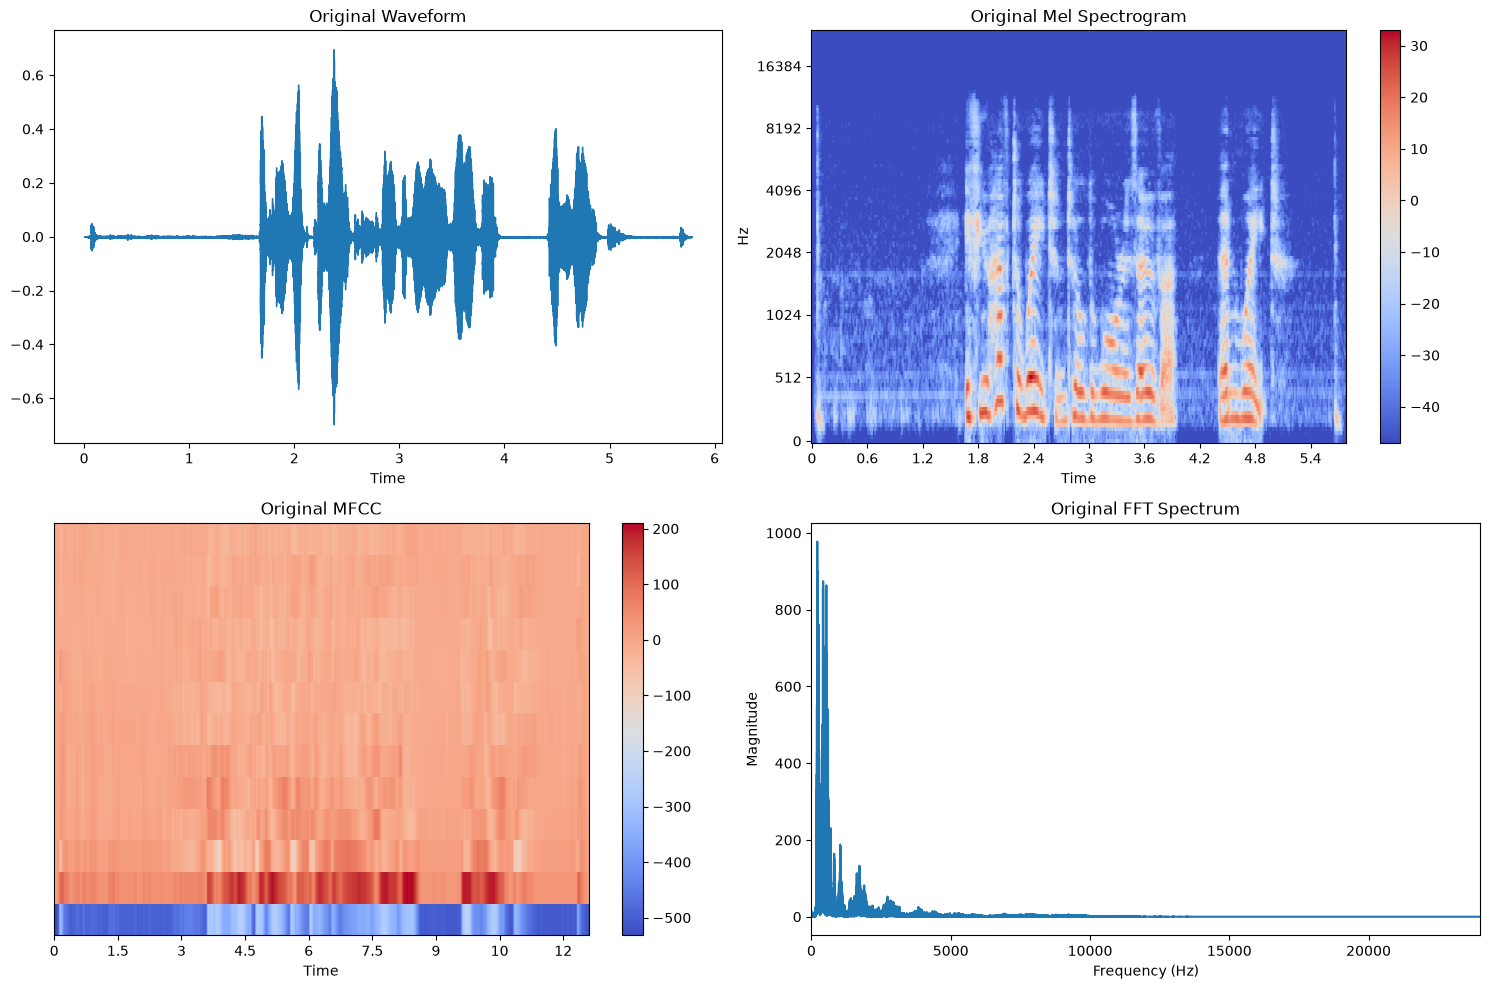

In [14]:
plot_audio_features(signal, sr=librosa.get_samplerate(audio_path), title="Original")

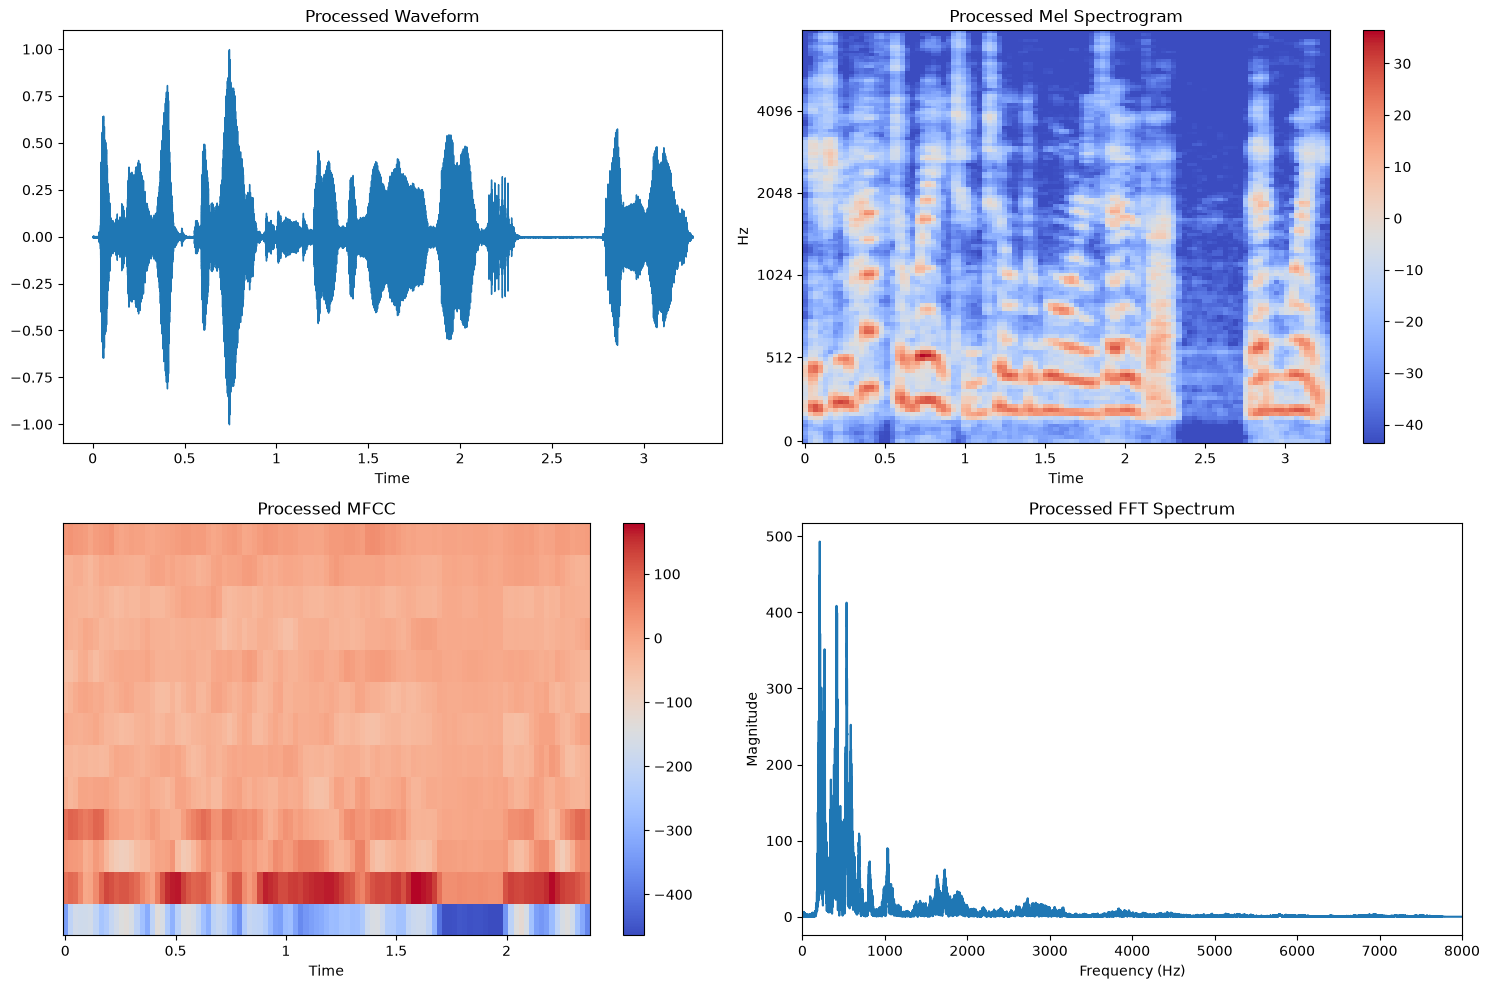

In [15]:
plot_audio_features(processed, sr=16000, title="Processed")